In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.3 MB/s eta 0:00:00


1-a) Generate adjacency matrix by Exclude hydrogen atoms, Continuous Distance Decay and Physicochemical Weight Estimation


In [ ]:
import numpy as np
from Bio.PDB import PDBParser, Selection
from Bio.PDB import PDBList # Import PDBList
import os # Import os for file path checking

# Standard amino acid classification for chemical estimation
RESIDUE_GROUPS = {
    'POSITIVE': {'ARG', 'LYS', 'HIS'},
    'NEGATIVE': {'ASP', 'GLU'},
    'AROMATIC': {'PHE', 'TYR', 'TRP'},
    'HYDROPHOBIC': {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PRO'}
}

def get_representative_atom(residue):
    """Returns C-beta atom if available, otherwise C-alpha (for Glycine)."""
    if 'CB' in residue:
        return residue['CB']
    elif 'CA' in residue:
        return residue['CA']
    return None

def generate_alternative_matrices(pdb_id="4OBE", chain_id='A'):

    pdb_id = pdb_id.lower()
    pdb_filename = f"{pdb_id}.pdb"

    # Add PDB file download logic
    if not os.path.exists(pdb_filename):
        print(f"正在從 RCSB 下載 {pdb_id.upper()} PDB 檔案...")
        pdbl = PDBList()
        downloaded_file = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="pdb")
        if os.path.exists(downloaded_file):
            os.rename(downloaded_file, pdb_filename)

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein',  pdb_filename)
    chain = structure[0][chain_id]

    # Filter standard residues
    residues = [r for r in chain if r.get_id()[0] == ' ' and ('CA' in r)]
    n = len(residues)

    # Initialize empty matrices
    all_atom_adj = np.zeros((n, n), dtype=int)
    decay_matrix = np.zeros((n, n), dtype=float)
    chemical_matrix = np.zeros((n, n), dtype=float)

    sigma = 5  # Scaling factor for continuous decay (in Angstroms)
    residue_name_map = {} # Initialize the residue name map

    for i in range(n):
        res1 = residues[i]
        residue_name_map[i] = f"{res1 .get_resname()}{res1.get_id()[1]}"
        for j in range(i, n):
            res2 = residues[j]



            # --- 1. All-Atom Minimum Distance Estimation ---
            # Exclude hydrogen atoms for consistency
            atoms1 = [a for a in res1.get_atoms() if a.element != 'H']
            atoms2 = [a for a in res2.get_atoms() if a.element != 'H']

            min_dist = float('inf')
            for a1 in atoms1:
                for a2 in atoms2:
                    dist = a1 - a2
                    if dist < min_dist:
                        min_dist = dist

            if min_dist <= 4.5:  # 4.5 Å threshold for all heavy atoms
                all_atom_adj[i, j] = all_atom_adj[j, i] = 1


            # --- 2. Continuous Distance Decay (RBF Kernel) ---
            # Using C-alpha distance for the continuous field
            ca_dist = res1['CA'] - res2['CA']
            weight = np.exp(- (ca_dist ** 2) / (2 * (sigma ** 2)))
            decay_matrix[i, j] = decay_matrix[j, i] = np.round(weight, 4)

            # --- 3. Physicochemical Weight Estimation ---
            if min_dist <= 5.0:  # Proximity condition
                name1, name2 = res1.get_resname(), res2.get_resname()
                chem_weight = 1.0  # Base physical proximity weight

                # Check for Salt Bridge (Positive - Negative)
                if (name1 in RESIDUE_GROUPS['POSITIVE'] and name2 in RESIDUE_GROUPS['NEGATIVE']) or \
                   (name1 in RESIDUE_GROUPS['NEGATIVE'] and name2 in RESIDUE_GROUPS['POSITIVE']):
                    chem_weight = 3.0

                # Check for Aromatic Stacking
                elif name1 in RESIDUE_GROUPS['AROMATIC'] and name2 in RESIDUE_GROUPS['AROMATIC']:
                    chem_weight = 2.5

                chemical_matrix[i, j] = chemical_matrix[j, i] = chem_weight
            if i==j:
              all_atom_adj[i,j]=0
              decay_matrix[i,j]=0
              chemical_matrix[i, j] = chemical_matrix[j, i] = 0

    return {
        "All_Atom_Binary": all_atom_adj,
        "Continuous_Decay": decay_matrix,
        "Physicochemical_Weighted": chemical_matrix,
        "residue_name": residue_name_map
        }


Adjacency Matrix (Continuous_Decay):
[[0.00000000e+00 9.92721070e-01 5.48305993e-01 ... 1.17787190e-02
  6.74960343e-03 5.29380628e-04]
 [9.92721070e-01 0.00000000e+00 9.93515115e-01 ... 6.64372711e-02
  3.08364218e-02 3.70566436e-03]
 [5.48305993e-01 9.93515115e-01 0.00000000e+00 ... 4.79089505e-02
  1.29698259e-02 1.72048709e-03]
 ...
 [1.17787190e-02 6.64372711e-02 4.79089505e-02 ... 0.00000000e+00
  9.91132902e-01 7.22736948e-01]
 [6.74960343e-03 3.08364218e-02 1.29698259e-02 ... 9.91132902e-01
  0.00000000e+00 9.91397636e-01]
 [5.29380628e-04 3.70566436e-03 1.72048709e-03 ... 7.22736948e-01
  9.91397636e-01 0.00000000e+00]]


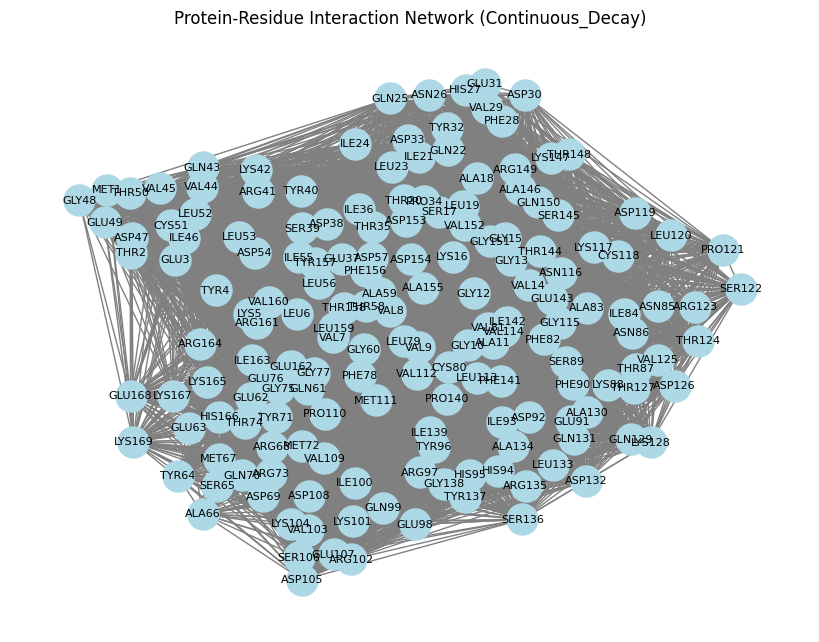

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
def normalize_matrix(matrix):
    np.fill_diagonal(matrix,0)
    if matrix.max() == 0:
        return matrix # Avoid division by zero if all elements are zero
    return matrix / matrix.max()
# Extract the residue name map

# Generate all alternative matrices and the residue name map
alt_matrices_data = generate_alternative_matrices(pdb_id="4OBE", chain_id='A')
residue_name_map = alt_matrices_data["residue_name"]

names="Continuous_Decay"
#names="All_Atom_Binary" # Exclude hydrogen atoms
#names="Physicochemical_Weighted"

# Extract the All-Atom Binary adjacency matrix and convert it to a NetworkX Graph
adj_matrix = normalize_matrix(alt_matrices_data[names])

residue_name_map = alt_matrices_data["residue_name"]

G = nx.from_numpy_array(adj_matrix)




print("Adjacency Matrix ("+names+"):")
print(adj_matrix)

# Save adjacency matrix to file

# Draw the network using the new G and residue_name_map
plt.figure(figsize=(8, 6))
nx.draw(G, labels=residue_name_map,node_color='lightblue', edge_color='gray', node_size=500, font_size=8)

plt.title("Protein-Residue Interaction Network ("+names+")")
plt.show()

1-b) Generate adjacency matrix by cutoff distant

/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8745.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8783.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8821.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8997.
  warnings.warn(


Adjacency Matrix:
[[0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]]


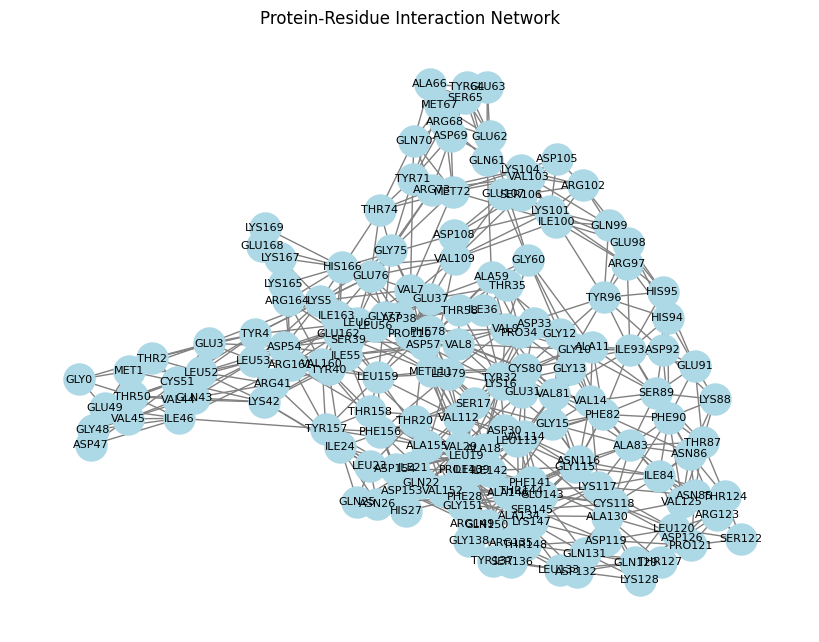

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from Bio import PDB
from Bio.PDB import PDBList

# Function to download PDB file from Protein Data Bank
def fetch_pdb(pdb_id):
    """Fetches a PDB file from the Protein Data Bank given a PDB ID."""
    pdbl = PDBList()
    pdb_file = pdbl.retrieve_pdb_file(pdb_id, file_format='pdb')
    return pdb_file

# Function to calculate the distance between two residues
def calculate_distance(residue_i, residue_j):
    """Calculates the Euclidean distance between the C-alpha atoms of two residues."""
    try:
        atom_i = residue_i["CA"].coord
        atom_j = residue_j["CA"].coord
        return np.linalg.norm(atom_i - atom_j)
    except KeyError:
        return float('inf')

# Function to construct a Protein-Residue Interaction Network
def construct_protein_residue_network(pdb_id, interaction_cutoff=8.0):
    """Constructs a residue interaction network from an online PDB file."""
    pdb_path = fetch_pdb(pdb_id)
    parser = PDB.PDBParser()
    structure = parser.get_structure("protein", pdb_path)
    G = nx.Graph()
    residue_name_map = {}

    for model in structure:
        for chain in model:
            for residue_i in chain:
                # Only consider standard amino acid residues
                if residue_i.get_id()[0] == ' ':
                    residue_id_i = residue_i.get_id()[1]
                    residue_name_map[residue_id_i] = f"{residue_i.get_resname()}{residue_id_i}"
                    G.add_node(residue_id_i) # Add node to ensure all residues are present

                    for residue_j in chain:
                        if residue_j.get_id()[0] == ' ':
                            residue_id_j = residue_j.get_id()[1]
                            residue_name_map[residue_id_j] = f"{residue_j.get_resname()}{residue_id_j}"

                            if residue_id_i != residue_id_j:
                                distance = calculate_distance(residue_i, residue_j)
                                if distance < interaction_cutoff:
                                    G.add_edge(residue_id_i, residue_id_j)
    return G, residue_name_map


# Example usage
pdb_id = "4OBE"  # Example PDB ID
interaction_cutoff = 8.0  # Distance cutoff in Angstroms
G, residue_name_map = construct_protein_residue_network(pdb_id, interaction_cutoff)

# Extract residue indices from the graph
residues = list(G.nodes())  # Extract nodes (residue IDs) from the network

# Function to create adjacency matrix
def create_adjacency_matrix(G, residues):
    """Creates an adjacency matrix from the interaction network."""
    residues = list(set(residues))  # Ensure uniqueness
    adjacency_matrix = nx.to_numpy_array(G, nodelist=residues)
    return adjacency_matrix


# Create adjacency matrix using the corrected residue list
adj_matrix = create_adjacency_matrix(G, residues)

print("Adjacency Matrix:")
#adj_matrix=generate_kras_biopython_matrix(pdb_id="4obe", chain_id="A", cutoff=7.3, max_res=166)[0]

print(adj_matrix)

# Save adjacency matrix to file
np.savetxt("adjacency_matrix.txt", adj_matrix, fmt="%d")

# Draw the network
plt.figure(figsize=(8, 6))
nx.draw(G, labels=residue_name_map, node_color='lightblue', edge_color='gray', node_size=500, font_size=8)

plt.title("Protein-Residue Interaction Network")
plt.show()

2-a)
Compute the eigenvector centrality(EC) by classical solver

Top Residues by Eigenvector Centrality:
Residue LEU79: 0.1096
Residue CYS80: 0.1080
Residue VAL8: 0.1075
Residue PHE78: 0.1067
Residue VAL9: 0.1060
Residue VAL81: 0.1050
Residue VAL114: 0.1041
Residue VAL7: 0.1040
Residue PHE156: 0.1039
Residue VAL112: 0.1034
Residue LEU113: 0.1033
Residue ALA155: 0.1026
Residue LYS16: 0.1026
Residue GLY10: 0.1025
Residue LEU6: 0.1009
Residue MET111: 0.0995
Residue LEU159: 0.0989
Residue ASP57: 0.0980
Residue GLY77: 0.0973
Residue PHE82: 0.0965
Residue THR58: 0.0964
Residue LEU56: 0.0962
Residue ILE55: 0.0955
Residue LEU19: 0.0955
Residue VAL152: 0.0950
Residue THR20: 0.0943
Residue GLY15: 0.0942
Residue ALA11: 0.0941
Residue SER17: 0.0937
Residue VAL14: 0.0933


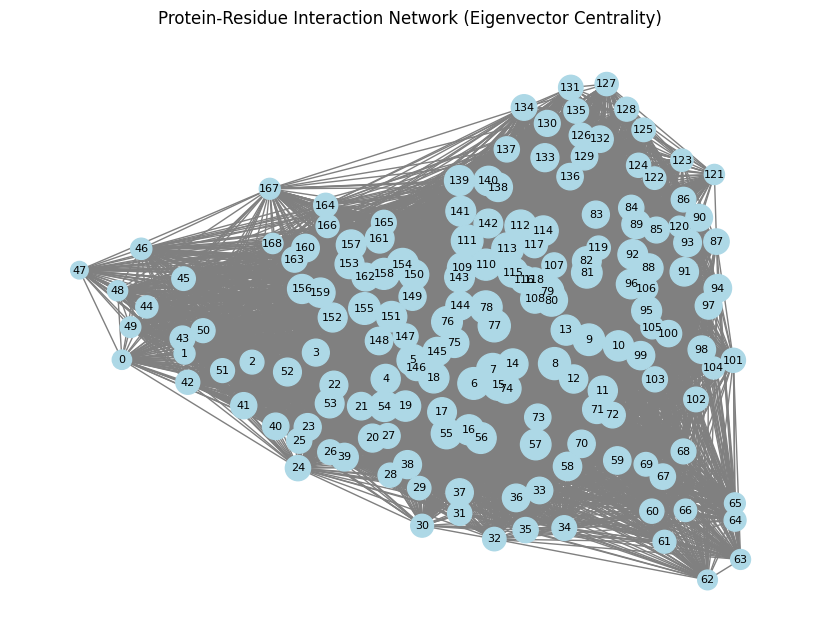

In [ ]:
def compute_eigenvector_centrality(G):
    """
    Computes the eigenvector centrality of the protein-residue interaction network.

    Parameters:
    G (networkx.Graph): The protein-residue interaction network.

    Returns:
    dict: A dictionary of nodes with their eigenvector centrality scores.
    """
    try:
        centrality = nx.eigenvector_centrality(G, max_iter=5000, tol=1e-6)
        return centrality
    except nx.NetworkXError as e:
        print(f"Eigenvector centrality calculation failed: {e}")
        return None

# Compute eigenvector centrality
eigenvector_centrality = compute_eigenvector_centrality(G)

# Print top residues by eigenvector centrality
print("Top Residues by Eigenvector Centrality:")
sorted_centrality = sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True)
for residue, score in sorted_centrality[:30]:  # Print top N residues
   # print(f"Residue {residue_name_map[residue]}: {score:.4f}")
    print(f"Residue {residue_name_map[residue]}: {score:.4f}")

# Visualization: Draw network with node sizes based on eigenvector centrality
plt.figure(figsize=(8, 6))
node_sizes = [5000 * eigenvector_centrality[node] for node in G.nodes()]  # Scale node sizes
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray',
        node_size=node_sizes, font_size=8)
plt.title("Protein-Residue Interaction Network (Eigenvector Centrality)")
plt.show()


2-b) QUBO: EC-top N

In [ ]:
!pip install dwave-hybrid
!pip install dwave-ocean-sdk
!pip install pyqubo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.2/170.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 2.5 

Solve by Simulated Annealing

In [ ]:
import networkx as nx
import numpy as np
from dimod import BinaryQuadraticModel, SimulatedAnnealingSampler

# Define constants

A = adj_matrix
n = len(A)
tau = 10  # Desired number of top nodes
P0 = 1 / np.sqrt(n)  # Based on the paper
P1 = 100 * n          # Stronger penalty to enforce the constraint

def calculate_d_hat(adj_matrix):
    d = np.sum(adj_matrix, axis=1)
    d_hat = d / np.linalg.norm(d)
    return d_hat

d_hat = calculate_d_hat(A)

# Construct C matrix
I = np.eye(n)
U = np.ones((n, n)) - I
C = (1 - 2 * tau) * I + U

# Construct Q matrix
Q = -P0 * (A @ A @ np.outer(d_hat, d_hat) @ A) \
    - P0 * (A @ np.outer(d_hat, d_hat) @ A @ A) \
    + P1 * C

# Convert to BQM
bqm = BinaryQuadraticModel.from_numpy_matrix(Q)

# Simulated annealing
import neal
sampler = neal.SimulatedAnnealingSampler()
response = sampler .sample(bqm, num_reads=1000, sweeps=1000, beta_range=(0.0001, 0.01))
#sampler = SimulatedAnnealingSampler()
#response = sampler.sample(bqm, num_reads=10000, beta_range=(0.1, 4.0))

# Filter solutions with exactly tau selected nodes
valid_solutions = []
for sample, energy in response.data(['sample', 'energy']):
    if sum(sample.values()) == tau:
        valid_solutions.append((sample, energy))

if valid_solutions:
    best_sample, best_energy = min(valid_solutions, key=lambda x: x[1])
    top_nodes = [node + 1 for node, val in best_sample.items() if val == 1]

    print("Best valid sample:", best_sample)
    print("Energy:", best_energy)
    print("Top nodes:", top_nodes)
else:
    print("No valid solution with exactly τ selected nodes.")

print("Top residues:")
for i in range(len(top_nodes)):
  print(residue_name_map[top_nodes[i]])


/tmp/ipykernel_1092/2363545152.py:31: DeprecationWarning: BQM.from_numpy_matrix(M) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Use BQM(M, "BINARY") instead.
  bqm = BinaryQuadraticModel.from_numpy_matrix(Q)


Best valid sample: {0: np.int8(0), 1: np.int8(0), 2: np.int8(0), 3: np.int8(0), 4: np.int8(0), 5: np.int8(0), 6: np.int8(1), 7: np.int8(0), 8: np.int8(0), 9: np.int8(0), 10: np.int8(0), 11: np.int8(0), 12: np.int8(0), 13: np.int8(0), 14: np.int8(0), 15: np.int8(0), 16: np.int8(0), 17: np.int8(0), 18: np.int8(0), 19: np.int8(0), 20: np.int8(0), 21: np.int8(0), 22: np.int8(0), 23: np.int8(0), 24: np.int8(0), 25: np.int8(0), 26: np.int8(0), 27: np.int8(0), 28: np.int8(0), 29: np.int8(0), 30: np.int8(0), 31: np.int8(0), 32: np.int8(0), 33: np.int8(0), 34: np.int8(0), 35: np.int8(0), 36: np.int8(0), 37: np.int8(0), 38: np.int8(0), 39: np.int8(0), 40: np.int8(0), 41: np.int8(0), 42: np.int8(0), 43: np.int8(0), 44: np.int8(0), 45: np.int8(0), 46: np.int8(0), 47: np.int8(0), 48: np.int8(0), 49: np.int8(0), 50: np.int8(0), 51: np.int8(0), 52: np.int8(0), 53: np.int8(0), 54: np.int8(0), 55: np.int8(1), 56: np.int8(1), 57: np.int8(0), 58: np.int8(0), 59: np.int8(0), 60: np.int8(0), 61: np.int8(0)

In [ ]:
#top 20
#Energy: -13521021.334910572
#Top nodes: [5, 7, 15, 22, 39, 56, 60, 61, 75, 76, 79, 80, 81, 86, 99, 101, 114, 116, 143, 149]

In [ ]:
#top 10
#Energy: -1690330.1372174025
#Top nodes: [16, 18, 79, 80, 82, 105, 114, 118, 145, 151]

In [ ]:
#top 5
#Energy: -211364.46442180127
#Top nodes: [19, 80, 114, 116, 156]

3) Decomposition Strategy


In [ ]:
import hybrid
from hybrid.decomposers import EnergyImpactDecomposer #ref[1]:https://docs.dwavequantum.com/en/latest/industrial_optimization/dwave_hybrid.html
from hybrid.core import State             #ref[2]:https://docs.dwavequantum.com/en/latest/ocean/api_ref_hybrid/decomposers.html#hybrid-decomposers-examples
from hybrid.utils import min_sample, flip_energy_gains


decomposer = EnergyImpactDecomposer(size=60, rolling=True, rolling_history=1.0)
state0 = State.from_sample(min_sample(bqm), bqm)
print(flip_energy_gains(bqm, state0.samples.first.sample))
state1 = decomposer.run(state0).result()
print(len(list(state1.subproblem.variables)),list(state1.subproblem.variables))

state2 = decomposer.run(state1).result()
print(len(list(state2.subproblem.variables)),list(state2.subproblem.variables))

state3 = decomposer.run(state1).result()
print(len(list(state3.subproblem.variables)),list(state3.subproblem.variables))



[(np.float64(-321100.08853020216), 62), (np.float64(-321100.09433062683), 168), (np.float64(-321100.1023948847), 47), (np.float64(-321100.1271428309), 63), (np.float64(-321100.1517745376), 46), (np.float64(-321100.1550222908), 167), (np.float64(-321100.20689016767), 30), (np.float64(-321100.21270227083), 0), (np.float64(-321100.21570194396), 121), (np.float64(-321100.2204650743), 120), (np.float64(-321100.2312417287), 48), (np.float64(-321100.23386672704), 64), (np.float64(-321100.2411685798), 65), (np.float64(-321100.2480291094), 32), (np.float64(-321100.2753304684), 61), (np.float64(-321100.2845819932), 60), (np.float64(-321100.30397774273), 29), (np.float64(-321100.30990532873), 106), (np.float64(-321100.3287272582), 34), (np.float64(-321100.35247109784), 104), (np.float64(-321100.3608276472), 1), (np.float64(-321100.3650157037), 166), (np.float64(-321100.370018371), 44), (np.float64(-321100.3885069301), 49), (np.float64(-321100.38967184373), 66), (np.float64(-321100.39215455245), 3

4. Convert to Ising model for QAOA

In [ ]:
! pip install qiskit-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 10.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=aa28cfe294bad4c05838ceb40f0d08d182dd0484141766963aaaa3ed937f7b44
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import NumPyMinimumEigensolver


In [ ]:
qubo = QuadraticProgram()
linear_lis=[]

for i in range(len(bqm.variables)):
    qubo.binary_var(str(bqm.variables[i]))
    linear_lis.append(bqm.linear[bqm.variables[i]])

# Create a mapping from variable names (strings) to Qiskit Optimization variable objects
var_map = {var.name: var for var in qubo.variables}

# Reconstruct the quadratic dictionary using Qiskit Optimization variable objects
qiskit_quadratic = {}
for (var_name1, var_name2), coeff in bqm.quadratic.items():

    qiskit_quadratic[(str(var_name1), str(var_name2))] = coeff

qubo.minimize(linear=linear_lis, quadratic=qiskit_quadratic)

print(qubo.prettyprint())

Problem name: 

Minimize
  33799.44571219995*0*1 + 33798.68157443404*0*10 + 33799.04575573066*0*100
  + 33799.28815936178*0*101 + 33799.201204637495*0*102 + 33799.17987179125*0*103
  + 33799.45220200377*0*104 + 33799.41014075434*0*105 + 33799.48607240953*0*106
  + 33799.32944072545*0*107 + 33798.861715800216*0*108 + 33798.47745216098*0*109
  + 33798.98739442808*0*11 + 33798.14362906944*0*110 + 33797.9997608766*0*111
  + 33797.97253072655*0*112 + 33797.79229046987*0*113 + 33797.94890673262*0*114
  + 33797.938611966514*0*115 + 33798.45445901771*0*116
  + 33798.722419496036*0*117 + 33799.18538560841*0*118 + 33799.31191494569*0*119
  + 33798.95512205614*0*12 + 33799.56593621277*0*120 + 33799.57091256542*0*121
  + 33799.23222172113*0*122 + 33799.25417044893*0*123 + 33798.97696174475*0*124
  + 33799.246486301716*0*125 + 33799.14921371387*0*126 + 33799.37028980649*0*127
  + 33799.23307635173*0*128 + 33798.79156741484*0*129 + 33798.318138309834*0*13
  + 33799.012041354355*0*130 + 33799.2579668

In [ ]:
#QUBO to Ising model for QAOA
op, offset = qubo.to_ising()
print("offset: {}".format(offset))
print("operator:")
print(op) #Qiskit:SparsePauliOp

offset: 92813038.45776506
operator:
SparsePauliOp(['...'],
              coeffs=[-1259003.32006205+0.j, -1258989.34910933+0.j, -1258963.80124666+0.j, ...,
     8449.88102707+0.j,     8449.9071714 +0.j,     8449.93953429+0.j])
